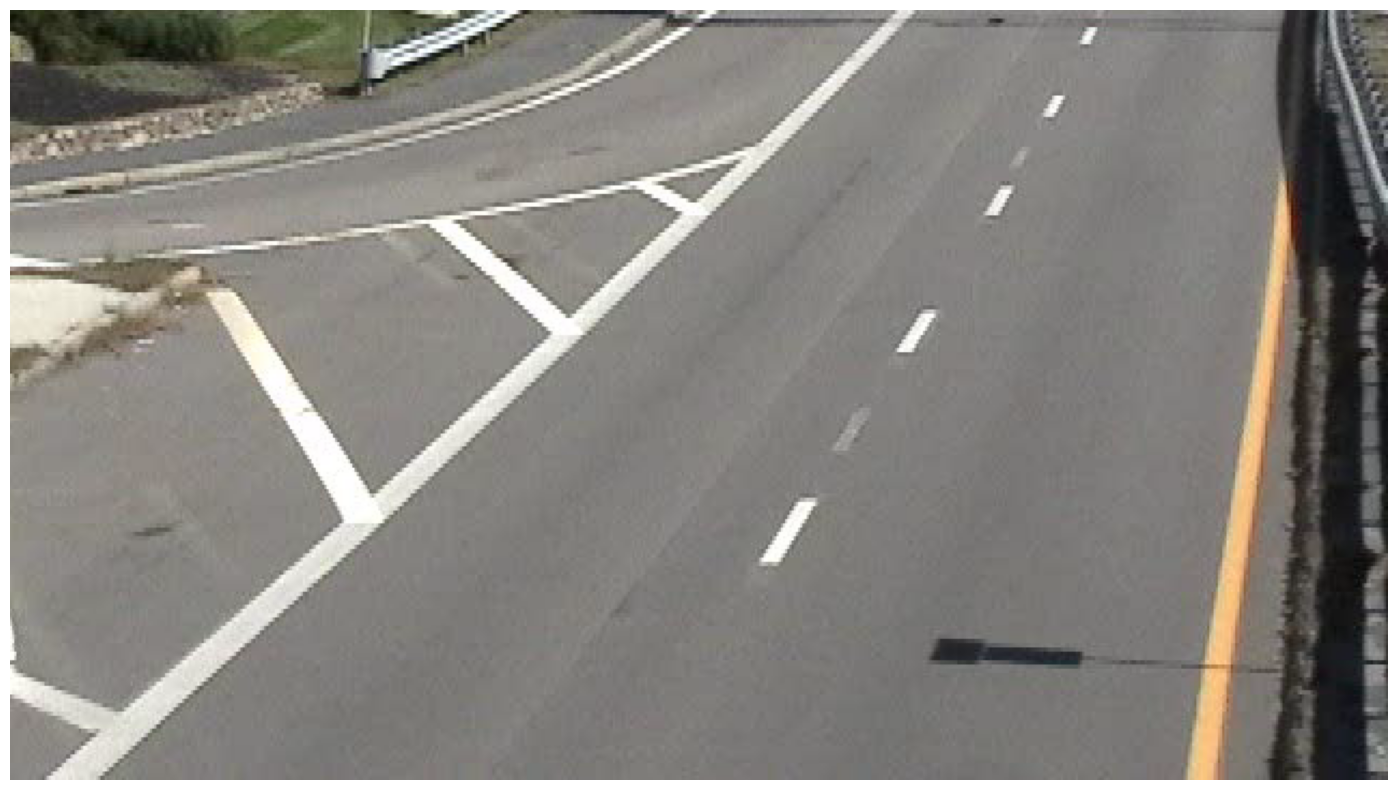

In [3]:
import cv2
import numpy as np
from skimage.measure import label, regionprops
from scipy.spatial import distance
import random

from matplotlib import pyplot as plt


def show(image: np.ndarray, height: float = 10):
    [img_height, img_width, *_] = image.shape
    aspect = img_width / img_height
    size = np.array([height * aspect, height])
    fig = plt.figure(figsize=size)
    ax = fig.add_subplot(1, 1, 1)
    if len(image.shape) == 2:
        ax.imshow(image, aspect="auto", cmap="gray")
    else:
        ax.imshow(image[..., ::-1], aspect="auto", cmap="hsv")
    ax.axis("off")
    plt.show()


vidReader = cv2.VideoCapture("visiontraffic.avi")
ret, frame = vidReader.read()
show(frame)
import random

vidReader = cv2.VideoCapture("visiontraffic.avi")

# skip remaining 89 frames
for _ in range(89):
    ret, frame = vidReader.read()

In [4]:
w = int(vidReader.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vidReader.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(vidReader.get(cv2.CAP_PROP_FPS))
codec = cv2.VideoWriter_fourcc(*"XVID")
out_annotated = cv2.VideoWriter("annotated.avi", codec, fps, (w, h))
out_thr = cv2.VideoWriter("thr.avi", codec, fps, (w, h), isColor=False)

In [5]:
prevGray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

tracks = []
next_id = 0

id_to_color = {}

MATCHING_THRESHOLD = 50
max_frames_lost = 20
min_detection_frames = 8

new_detections = []

while True:
    ret, frame = vidReader.read()
    if not ret:
        break

    frameGray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prevGray, frameGray, None, 0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    thr = mag > 1

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thr = cv2.morphologyEx(thr.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    thr = cv2.erode(thr, kernel, iterations=10)
    thr = cv2.dilate(thr, kernel, iterations=2)

    out_thr.write(thr.astype(np.uint8) * 255)

    labeled_thr = label(thr)
    props = regionprops(labeled_thr)

    detections = []

    for prop in props:
        if prop.area > 1000:
            det = {}
            minr, minc, maxr, maxc = prop.bbox
            x, y, w, h = minc, minr, maxc - minc, maxr - minr

            det["bb"] = [x, y, w, h]

            dirbb = ang[y : y + h, x : x + w]
            det["dir"] = np.mean(dirbb[dirbb != 0])
            spdbb = mag[y : y + h, x : x + w]
            det["spd"] = np.mean(spdbb[spdbb > 2])
            det["cc"] = prop.centroid
            det["lbl"] = prop.area
            detections.append(det)

    updated_tracks = []
    unmatched_detections = detections[:]
    for track in tracks:
        if not detections:
            break

        dists = [distance.euclidean(track["cc"], det["cc"]) for det in detections]
        min_dist_idx = np.argmin(dists)
        if dists[min_dist_idx] < MATCHING_THRESHOLD:
            track["bb"] = detections[min_dist_idx]["bb"]
            track["cc"] = detections[min_dist_idx]["cc"]
            track["dir"] = detections[min_dist_idx]["dir"]
            track["spd"] = detections[min_dist_idx]["spd"]
            track["lbl"] = detections[min_dist_idx]["lbl"]
            track["history"].append(track["cc"])
            track["frames_lost"] = 0
            updated_tracks.append(track)
            unmatched_detections.remove(detections[min_dist_idx])
            detections.remove(detections[min_dist_idx])
        else:
            track["frames_lost"] += 1
            if track["frames_lost"] <= max_frames_lost:
                updated_tracks.append(track)

    new_detections_temp = []
    unmatched_new_detections = new_detections[:]
    for det in unmatched_detections:
        matched = False
        for new_det in new_detections:
            if distance.euclidean(det["cc"], new_det["cc"]) < MATCHING_THRESHOLD:
                new_det["det_count"] += 1
                new_det["lost_count"] = 0
                new_det["bb"] = det["bb"]
                new_det["cc"] = det["cc"]
                new_det["dir"] = det["dir"]
                new_det["spd"] = det["spd"]
                new_det["lbl"] = det["lbl"]
                if new_det["det_count"] >= min_detection_frames:
                    new_det["id"] = next_id
                    new_det["history"] = [new_det["cc"]]
                    next_id += 1
                    id_to_color[new_det["id"]] = (
                        random.randint(0, 255),
                        random.randint(0, 255),
                        random.randint(0, 255),
                    )
                    updated_tracks.append(new_det)
                else:
                    new_detections_temp.append(new_det)

                matched = True

                break
        if not matched:
            det["det_count"] = 1
            det["lost_count"] = 0
            new_detections_temp.append(det)

    new_detections = new_detections_temp
    tracks = updated_tracks

    ann = frame.copy()
    for track in tracks:
        x, y, w, h = track["bb"]
        cv2.rectangle(ann, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            ann,
            f"ID: {track['id']} Area: {track['lbl']}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2,
        )

        x1, y1 = int(track["cc"][1]), int(track["cc"][0])
        x2 = int(x1 + 5 * track["spd"] * np.cos(track["dir"]))
        y2 = int(y1 + 5 * track["spd"] * np.sin(track["dir"]))
        cv2.line(ann, (x1, y1), (x2, y2), (0, 255, 0), 3)

        color = id_to_color[track["id"]]
        for point in track["history"]:
            cv2.circle(ann, (int(point[1]), int(point[0])), 3, color, -1)

    out_annotated.write(ann)

    prevGray = frameGray


vidReader.release()
out_annotated.release()
out_thr.release()
cv2.destroyAllWindows()
